In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import linregress, ttest_ind
from statsmodels.stats.multitest import multipletests
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv("/om/user/kspiv/aurora/data/20260203_avGFP.csv", header=None, index_col=0)

In [3]:
# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

class ProteinFluorescenceAnalyzer:
    def __init__(self, avgfp_rep1, mcherry_rep1, avgfp_rep2, mcherry_rep2):
        """
        Initialize analyzer with plate reader data as lists
        
        Parameters:
        -----------
        avgfp_rep1 : list
            avGFP values for replicate 1, in well order A1-A12, B1-B12, C1-C12, D1-D11
        mcherry_rep1 : list
            mCherry values for replicate 1, same order
        avgfp_rep2 : list
            avGFP values for replicate 2
        mcherry_rep2 : list
            mCherry values for replicate 2
        """
        self.create_dataframe(avgfp_rep1, mcherry_rep1, avgfp_rep2, mcherry_rep2)
    
    def create_dataframe(self, avgfp_rep1, mcherry_rep1, avgfp_rep2, mcherry_rep2):
        """Convert lists to dataframe with well labels"""
        # Generate well names: A1-A12, B1-B12, C1-C12, D1-D11
        wells = []
        for row in ['A', 'B', 'C']:
            for col in range(1, 13):
                wells.append(f"{row}{col}")
        for col in range(1, 12):  # D1-D11
            wells.append(f"D{col}")
        
        # Create records for both replicates
        records = []
        
        # Replicate 1
        for well, gfp, mch in zip(wells, avgfp_rep1, mcherry_rep1):
            records.append({
                'well': well,
                'replicate': 1,
                'avgfp_raw': float(gfp),
                'mcherry_raw': float(mch)
            })
        
        # Replicate 2
        for well, gfp, mch in zip(wells, avgfp_rep2, mcherry_rep2):
            records.append({
                'well': well,
                'replicate': 2,
                'avgfp_raw': float(gfp),
                'mcherry_raw': float(mch)
            })
        
        self.df = pd.DataFrame(records)
        print(f"Created dataframe with {len(self.df)} measurements ({len(wells)} wells × 2 replicates)")
    
    def add_variant_info(self, variant_dict, wt_wells, blank_wells):
        """
        Add variant information to dataframe
        
        Parameters:
        -----------
        variant_dict : dict
            Mapping of well -> variant name, e.g. {'A1': 'WT', 'A2': 'Variant1', ...}
        wt_wells : list
            List of wells containing wildtype, e.g. ['A1', 'A2']
        blank_wells : list
            List of blank wells, e.g. ['D10', 'D11']
        """
        self.df['variant_name'] = self.df['well'].map(variant_dict)
        self.df['is_wt'] = self.df['well'].isin(wt_wells)
        self.df['is_blank'] = self.df['well'].isin(blank_wells)
        
        # Fill any unmapped wells as 'Unknown'
        self.df['variant_name'] = self.df['variant_name'].fillna('Unknown')
        
        print(f"\nVariant assignment:")
        print(f"  Wildtype wells: {len([w for w in wt_wells])}")
        print(f"  Blank wells: {len(blank_wells)}")
        print(f"  Variant wells: {len(self.df[~self.df['is_wt'] & ~self.df['is_blank']]) // 2}")
    
    def background_subtraction(self, expression_threshold_pct=0.10):
        """
        Subtract background fluorescence and mark low-expression wells
        
        Parameters:
        -----------
        expression_threshold_pct : float
            Fraction of WT median mCherry below which wells are considered low-expression
            Default: 0.10 (10% of WT)
        """
        blank_data = self.df[self.df['is_blank'] == True]
        
        if len(blank_data) == 0:
            print("Warning: No blank wells found. Using median of bottom 5% as background.")
            gfp_bg = self.df['avgfp_raw'].quantile(0.05)
            mch_bg = self.df['mcherry_raw'].quantile(0.05)
        else:
            gfp_bg = blank_data['avgfp_raw'].median()
            mch_bg = blank_data['mcherry_raw'].median()
        
        print(f"\nBackground levels - GFP: {gfp_bg:.1f}, mCherry: {mch_bg:.1f}")
        
        # Background subtraction
        self.df['avgfp_corrected'] = self.df['avgfp_raw'] - gfp_bg
        self.df['mcherry_corrected'] = self.df['mcherry_raw'] - mch_bg
        
        # Get WT median for thresholds
        wt_mch_median = self.df[self.df['is_wt'] == True]['mcherry_raw'].median()
        wt_gfp_median = self.df[self.df['is_wt'] == True]['avgfp_raw'].median()
        
        # STEP 1: Set numerical floor (1% of WT median) for clipping
        min_threshold_mch = 0.01 * wt_mch_median
        min_threshold_gfp = 0.01 * wt_gfp_median
        
        # Store pre-clipped values for floor detection
        self.df['mcherry_preclip'] = self.df['mcherry_corrected'].copy()
        self.df['avgfp_preclip'] = self.df['avgfp_corrected'].copy()
        
        # Apply clipping
        self.df['avgfp_corrected'] = self.df['avgfp_corrected'].clip(lower=min_threshold_gfp)
        self.df['mcherry_corrected'] = self.df['mcherry_corrected'].clip(lower=min_threshold_mch)
        
        print(f"Numerical floor set to: {min_threshold_mch:.1f} (1% of WT median mCherry)")
        
        # STEP 2: Mark wells that hit the floor
        self.df['hit_mcherry_floor'] = (
            self.df['mcherry_preclip'] < min_threshold_mch 
        )
        self.df['hit_avgfp_floor'] = (
            self.df['avgfp_preclip'] < min_threshold_gfp 
        )
        
        # STEP 3: Set biological expression threshold (10% of WT by default)
        expr_threshold = expression_threshold_pct * wt_mch_median
        self.df['low_expression'] = self.df['mcherry_preclip'] < expr_threshold #self.df['mcherry_raw'] < expr_threshold
        
        print(f"Expression threshold set to: {expr_threshold:.1f} ({expression_threshold_pct*100:.0f}% of WT mCherry)")
        
        # Report exclusions
        n_floor = self.df['hit_mcherry_floor'].sum()
        n_low_expr = self.df['low_expression'].sum()
        print(f"\nQuality control:")
        print(f"  Wells hitting mCherry floor: {n_floor}")
        print(f"  Wells below expression threshold: {n_low_expr}")
        print(f"  Total excluded from analysis: {self.df['low_expression'].sum()}")
        
        self.gfp_bg = gfp_bg
        self.mch_bg = mch_bg
        self.expr_threshold = expr_threshold
        self.min_threshold = min_threshold_mch
    
    def fit_wildtype_model(self):
        """Fit linear model for wildtype: GFP = alpha * mCherry"""
        wt_data = self.df[self.df['is_wt'] == True]
        
        if len(wt_data) == 0:
            raise ValueError("No wildtype wells specified!")
        
        # Fit through origin (no intercept)
        X = wt_data['mcherry_corrected'].values
        y = wt_data['avgfp_corrected'].values
        
        # Linear regression through origin
        self.wt_alpha = np.sum(X * y) / np.sum(X ** 2)
        
        # Calculate correct standard error for slope
        residuals = y - self.wt_alpha * X
        n = len(X)
        self.wt_alpha_se = np.sqrt(np.sum(residuals**2) / ((n - 1) * np.sum(X**2)))
        
        # Also calculate with intercept for comparison
        slope, intercept, r_value, p_value, std_err = linregress(X, y)
        
        print(f"\nWildtype model:")
        print(f"  Slope (through origin): {self.wt_alpha:.3f} ± {self.wt_alpha_se:.3f}")
        print(f"  Slope (with intercept): {slope:.3f}, Intercept: {intercept:.1f}")
        print(f"  R² (with intercept): {r_value**2:.3f}")
        print(f"  N measurements: {len(wt_data)}")
        
        self.wt_slope = slope
        self.wt_intercept = intercept
        self.wt_r2 = r_value**2
        
        # Store WT data for plotting
        self.wt_data = wt_data
    
    def calculate_relative_activities(self, method='slope'):
        """
        Calculate relative activity for each variant
        
        Parameters:
        -----------
        method : str
            'slope' - fit slope for each variant and compare to WT
            'residual' - calculate residual from WT prediction
        """
        # STEP 3: Exclude blanks, WT, AND low-expression wells
        variant_data = self.df[
            (~self.df['is_blank']) &
            (~self.df['is_wt']) &
            (~self.df['low_expression'])  # ← KEY EXCLUSION
        ].copy()
        
        print(f"\nAnalyzing {len(variant_data)} valid measurements from variants")
        
        if method == 'slope':
            # Fit slope for each variant
            results = []
            for variant in self.df[~self.df['is_blank'] & ~self.df['is_wt']]['variant_name'].unique():
                # Get data for this variant (after exclusions)
                var_df = variant_data[variant_data['variant_name'] == variant]
                
                # STEP 4: Guard against variants with no valid points
                if len(var_df) == 0:
                    results.append({
                        'variant': variant,
                        'alpha': np.nan,
                        'alpha_se': np.nan,
                        'relative_activity': np.nan,
                        'fold_change': np.nan,
                        'n_replicates': 0,
                        'n_excluded': len(self.df[
                            (self.df['variant_name'] == variant) & 
                            (~self.df['is_blank']) & 
                            (~self.df['is_wt'])
                        ]),
                        'sem': np.nan,
                        'exclusion_reason': 'low_expression'
                    })
                    continue
                
                X = var_df['mcherry_corrected'].values
                y = var_df['avgfp_corrected'].values
                
                if len(X) < 2:
                    print(f"Warning: Only {len(X)} valid measurement for {variant}, using ratio method")
                    # Fall back to simple ratio
                    alpha_var = np.mean(y / X)
                    relative_activity = alpha_var / self.wt_alpha
                    se_alpha = np.std(y / X) / np.sqrt(len(X)) if len(X) > 1 else np.nan
                    sem = se_alpha / self.wt_alpha if not np.isnan(se_alpha) else np.nan
                else:
                    # Fit through origin
                    alpha_var = np.sum(X * y) / np.sum(X ** 2)
                    relative_activity = alpha_var / self.wt_alpha
                    
                    # Correct SEM calculation for slope
                    residuals = y - alpha_var * X
                    n = len(X)
                    se_alpha = np.sqrt(np.sum(residuals**2) / ((n - 1) * np.sum(X**2)))
                    
                    # Propagate error to relative activity
                    sem = relative_activity * np.sqrt(
                        (se_alpha / alpha_var)**2 + (self.wt_alpha_se / self.wt_alpha)**2
                    )
                
                results.append({
                    'variant': variant,
                    'alpha': alpha_var,
                    'alpha_se': se_alpha if len(X) >= 2 else np.nan,
                    'relative_activity': relative_activity,
                    'fold_change': relative_activity,
                    'n_replicates': len(X),
                    'n_excluded': len(self.df[
                        (self.df['variant_name'] == variant) & 
                        (~self.df['is_blank']) & 
                        (~self.df['is_wt']) &
                        (self.df['low_expression'])
                    ]),
                    'sem': sem,
                    'exclusion_reason': None
                })
            
            self.results = pd.DataFrame(results)
            
        elif method == 'residual':
            # Calculate residuals from WT model
            variant_data['gfp_predicted_wt'] = self.wt_alpha * variant_data['mcherry_corrected']
            variant_data['residual'] = variant_data['avgfp_corrected'] - variant_data['gfp_predicted_wt']
            variant_data['relative_activity'] = variant_data['avgfp_corrected'] / variant_data['gfp_predicted_wt']
            
            # Aggregate by variant
            results = variant_data.groupby('variant_name').agg({
                'relative_activity': ['mean', 'sem', 'count'],
                'residual': ['mean', 'sem']
            }).reset_index()
            
            results.columns = ['variant', 'fold_change', 'fold_change_sem', 'n_replicates', 
                             'residual_mean', 'residual_sem']
            
            self.results = results
            self.variant_data = variant_data
        
        # Add statistical test vs WT
        self.add_statistical_tests()
        
        # Add multiple hypothesis correction
        self.add_multiple_testing_correction()
        
        return self.results
    
    def add_statistical_tests(self):
        """
        Use log-ratios for t-test to stabilize variance
        EXCLUDES low-expression wells
        """
        wt_gfp = self.wt_data['avgfp_corrected'].values
        wt_mch = self.wt_data['mcherry_corrected'].values
        wt_log_ratio = np.log(wt_gfp / wt_mch)
        
        p_values = []
        for variant in self.results['variant']:
            # STEP 5: Exclude low-expression wells from statistics
            var_df = self.df[
                (self.df['variant_name'] == variant) & 
                (~self.df['is_wt']) & 
                (~self.df['is_blank']) &
                (~self.df['low_expression'])  # ← KEY EXCLUSION
            ]
            
            if len(var_df) < 2:
                p_values.append(np.nan)
            else:
                var_gfp = var_df['avgfp_corrected'].values
                var_mch = var_df['mcherry_corrected'].values
                var_log_ratio = np.log(var_gfp / var_mch)
                
                # Use Welch's t-test (doesn't assume equal variance)
                _, p_val = ttest_ind(var_log_ratio, wt_log_ratio, equal_var=False)
                p_values.append(p_val)
        
        self.results['p_value'] = p_values
        self.results['significant'] = self.results['p_value'] < 0.05
    
    def add_multiple_testing_correction(self):
        """Add FDR correction for multiple hypothesis testing"""
        valid_pvals = self.results['p_value'].dropna()
        
        if len(valid_pvals) > 1:
            # Benjamini-Hochberg FDR correction
            _, q_values, _, _ = multipletests(
                self.results['p_value'].fillna(1.0), 
                method='fdr_bh'
            )
            self.results['q_value'] = q_values
            self.results['significant_fdr'] = self.results['q_value'] < 0.05
            
            print(f"\nMultiple testing correction applied:")
            print(f"  Uncorrected significant (p < 0.05): {self.results['significant'].sum()}")
            print(f"  FDR-corrected significant (q < 0.05): {self.results['significant_fdr'].sum()}")
        else:
            self.results['q_value'] = self.results['p_value']
            self.results['significant_fdr'] = self.results['significant']
    
    def bootstrap_confidence_interval(self, variant_name, n_bootstrap=10000, confidence=0.95):
        """
        Bootstrap confidence interval for relative activity
        More robust than parametric SEM, especially with small n
        """
        var_data = self.df[
            (self.df['variant_name'] == variant_name) &
            (~self.df['low_expression'])  # Exclude low-expression
        ]
        wt_data = self.wt_data
        
        if len(var_data) < 2:
            print(f"Warning: {variant_name} has insufficient valid data for bootstrap")
            return np.nan, np.nan, np.array([])
        
        var_gfp = var_data['avgfp_corrected'].values
        var_mch = var_data['mcherry_corrected'].values
        wt_gfp = wt_data['avgfp_corrected'].values
        wt_mch = wt_data['mcherry_corrected'].values
        
        # Bootstrap
        rng = np.random.default_rng(42)
        bootstrap_ratios = []
        
        for _ in range(n_bootstrap):
            # Resample variant
            idx_var = rng.choice(len(var_gfp), size=len(var_gfp), replace=True)
            alpha_var = np.sum(var_mch[idx_var] * var_gfp[idx_var]) / np.sum(var_mch[idx_var]**2)
            
            # Resample WT
            idx_wt = rng.choice(len(wt_gfp), size=len(wt_gfp), replace=True)
            alpha_wt = np.sum(wt_mch[idx_wt] * wt_gfp[idx_wt]) / np.sum(wt_mch[idx_wt]**2)
            
            bootstrap_ratios.append(alpha_var / alpha_wt)
        
        bootstrap_ratios = np.array(bootstrap_ratios)
        
        # Calculate confidence interval
        alpha_lower = (1 - confidence) / 2
        alpha_upper = 1 - alpha_lower
        ci_lower = np.percentile(bootstrap_ratios, alpha_lower * 100)
        ci_upper = np.percentile(bootstrap_ratios, alpha_upper * 100)
        
        return ci_lower, ci_upper, bootstrap_ratios
    
    def plot_scatter(self, figsize=(10, 8), save_path=None, show_excluded=True):
        """Plot GFP vs mCherry scatter with WT regression line"""
        fig, ax = plt.subplots(figsize=figsize)
        
        # Plot WT points and line
        ax.scatter(self.wt_data['mcherry_corrected'], 
                  self.wt_data['avgfp_corrected'],
                  c='gray', alpha=0.5, s=100, label='Wildtype', zorder=1)
        
        # WT regression line
        x_range = np.linspace(0, self.df['mcherry_corrected'].max() * 1.1, 100)
        y_pred = self.wt_alpha * x_range
        ax.plot(x_range, y_pred, 'k--', linewidth=2, 
               label=f'WT fit (slope={self.wt_alpha:.3f}±{self.wt_alpha_se:.3f})', zorder=2)
        
        # Plot valid variants
        variant_data = self.df[~self.df['is_blank'] & ~self.df['is_wt'] & ~self.df['low_expression']]
        
        if 'variant_name' in variant_data.columns:
            unique_variants = variant_data['variant_name'].unique()
            colors = sns.color_palette("husl", len(unique_variants))
            
            for i, variant in enumerate(unique_variants):
                var_df = variant_data[variant_data['variant_name'] == variant]
                if len(var_df) > 0:
                    ax.scatter(var_df['mcherry_corrected'], 
                              var_df['avgfp_corrected'],
                              c=[colors[i]], s=120, label=variant, 
                              edgecolors='black', linewidth=0.5, zorder=3)
        
        # Optionally show excluded points
        if show_excluded:
            excluded_data = self.df[~self.df['is_blank'] & ~self.df['is_wt'] & self.df['low_expression']]
            if len(excluded_data) > 0:
                ax.scatter(excluded_data['mcherry_corrected'], 
                          excluded_data['avgfp_corrected'],
                          c='lightgray', s=80, alpha=0.3, 
                          label='Excluded (low expression)', 
                          edgecolors='red', linewidth=1, zorder=0, marker='x')
        
        # Add expression threshold line
        if hasattr(self, 'expr_threshold'):
            ax.axvline(x=self.expr_threshold, color='red', linestyle=':', 
                      linewidth=2, alpha=0.5, label=f'Expression threshold')
        
        ax.set_xlabel('mCherry Fluorescence (Background-Corrected)', fontsize=12)
        ax.set_ylabel('avGFP Fluorescence (Background-Corrected)', fontsize=12)
        ax.set_title('GFP vs mCherry Expression Control', fontsize=14, fontweight='bold')
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
        ax.grid(True, alpha=0.3)
        
        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()
    
    def plot_expression_activity_2d(self, figsize=(12, 5), save_path=None):
        """
        2D plot showing expression vs activity
        Makes low-expression artifacts visually obvious
        """
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
        
        # Get variant data (all, including excluded)
        all_variant_data = self.df[~self.df['is_blank'] & ~self.df['is_wt']].copy()
        all_variant_data['ratio'] = (all_variant_data['avgfp_corrected'] / 
                                      all_variant_data['mcherry_corrected'])
        
        # Plot 1: Expression vs Ratio
        valid_mask = ~all_variant_data['low_expression']
        
        ax1.scatter(all_variant_data[valid_mask]['mcherry_raw'],
                   all_variant_data[valid_mask]['ratio'],
                   c='blue', alpha=0.6, s=80, label='Valid', edgecolors='black', linewidth=0.5)
        
        ax1.scatter(all_variant_data[~valid_mask]['mcherry_raw'],
                   all_variant_data[~valid_mask]['ratio'],
                   c='red', alpha=0.3, s=80, label='Excluded', 
                   marker='x', linewidth=2)
        
        # Add WT median ratio
        wt_ratio_median = np.median(self.wt_data['avgfp_corrected'] / self.wt_data['mcherry_corrected'])
        ax1.axhline(y=wt_ratio_median, color='gray', linestyle='--', linewidth=2, label='WT median')
        
        # Add expression threshold
        ax1.axvline(x=self.expr_threshold, color='red', linestyle=':', linewidth=2, alpha=0.5)
        
        ax1.set_xlabel('mCherry (raw)', fontsize=11)
        ax1.set_ylabel('GFP / mCherry Ratio', fontsize=11)
        ax1.set_title('Expression vs Activity Ratio', fontsize=12, fontweight='bold')
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        
        # Plot 2: Histogram of ratios (valid vs excluded)
        ax2.hist(all_variant_data[valid_mask]['ratio'], bins=20, 
                alpha=0.7, color='blue', edgecolor='black', label='Valid')
        ax2.hist(all_variant_data[~valid_mask]['ratio'], bins=20,
                alpha=0.5, color='red', edgecolor='black', label='Excluded')
        ax2.axvline(x=wt_ratio_median, color='gray', linestyle='--', linewidth=2)
        ax2.set_xlabel('GFP / mCherry Ratio', fontsize=11)
        ax2.set_ylabel('Frequency', fontsize=11)
        ax2.set_title('Distribution of Activity Ratios', fontsize=12, fontweight='bold')
        ax2.legend()
        ax2.grid(True, alpha=0.3, axis='y')
        
        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()
    
    def plot_relative_activity(self, figsize=(10, 6), save_path=None, use_fdr=True, show_excluded=True):
        """Plot bar chart of relative activities"""
        fig, ax = plt.subplots(figsize=figsize)
        
        results_sorted = self.results.sort_values('fold_change', ascending=False)
        
        # Separate valid and excluded variants
        valid_results = results_sorted[results_sorted['n_replicates'] > 0]
        excluded_results = results_sorted[results_sorted['n_replicates'] == 0]
        
        # Color bars based on significance
        sig_col = 'significant_fdr' if use_fdr and 'significant_fdr' in valid_results.columns else 'significant'
        colors = []
        for idx, row in valid_results.iterrows():
            if row[sig_col]:
                colors.append('#2ecc71')  # Green for significant
            else:
                colors.append('#95a5a6')  # Gray for not significant
        
        x_pos = np.arange(len(valid_results))
        bars = ax.bar(x_pos, valid_results['fold_change'], 
                     color=colors, edgecolor='black', linewidth=1.5)
        
        # Add error bars
        if 'sem' in valid_results.columns:
            ax.errorbar(x_pos, valid_results['fold_change'],
                       yerr=valid_results['sem'],
                       fmt='none', ecolor='black', capsize=5, linewidth=2)
        
        # Add horizontal line at 1.0 (WT level)
        ax.axhline(y=1.0, color='red', linestyle='--', linewidth=2, 
                  label='Wildtype', zorder=0)
        
        # Formatting
        ax.set_xticks(x_pos)
        ax.set_xticklabels(valid_results['variant'], rotation=45, ha='right')
        ax.set_ylabel('Relative Activity (Fold-Change vs WT)', fontsize=12)
        ax.set_xlabel('Variant', fontsize=12)
        title = 'GFP Activity Normalized to Expression'
        if use_fdr:
            title += ' (FDR-corrected significance)'
        ax.set_title(title, fontsize=14, fontweight='bold')
        ax.legend()
        ax.grid(True, alpha=0.3, axis='y')
        
        # Add significance stars
        for i, (idx, row) in enumerate(valid_results.iterrows()):
            if row[sig_col]:
                y_pos = row['fold_change'] + row.get('sem', 0)
                ax.text(i, y_pos + 0.05, '*', ha='center', fontsize=16, fontweight='bold')
        
        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()
        
        # Print excluded variants
        if show_excluded and len(excluded_results) > 0:
            print(f"\nExcluded variants (n={len(excluded_results)}):")
            for idx, row in excluded_results.iterrows():
                print(f"  {row['variant']}: {row['n_excluded']} measurements below expression threshold")
    
    def plot_residuals(self, figsize=(12, 5), save_path=None, include_wt=True):
        """Plot residual diagnostics"""
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
        
        # Include WT and valid variants only
        if include_wt:
            all_data = self.df[~self.df['is_blank'] & ~self.df['low_expression']].copy()
            label_suffix = " (valid data)"
        else:
            all_data = self.df[~self.df['is_blank'] & ~self.df['is_wt'] & ~self.df['low_expression']].copy()
            label_suffix = " (variants only)"
        
        all_data['gfp_predicted'] = self.wt_alpha * all_data['mcherry_corrected']
        all_data['residual'] = all_data['avgfp_corrected'] - all_data['gfp_predicted']
        
        # Residuals vs predicted
        colors = ['gray' if wt else 'red' for wt in all_data['is_wt']]
        ax1.scatter(all_data['gfp_predicted'], all_data['residual'],
        c=colors, alpha=0.6, s=80, edgecolors='black', linewidth=0.5)
        ax1.axhline(y=0, color='blue', linestyle='--', linewidth=2)
        ax1.set_xlabel('Predicted GFP (from WT model)', fontsize=11)
        ax1.set_ylabel('Residual', fontsize=11)
        ax1.set_title(f'Residuals vs Predicted{label_suffix}', fontsize=12, fontweight='bold')
        ax1.grid(True, alpha=0.3)

        if include_wt:
            from matplotlib.patches import Patch
            legend_elements = [
                Patch(facecolor='gray', label='WT'),
                Patch(facecolor='red', label='Variants')
            ]
            ax1.legend(handles=legend_elements)
        
        # Histogram of residuals
        ax2.hist(all_data['residual'], bins=20, edgecolor='black', alpha=0.7)
        ax2.axvline(x=0, color='blue', linestyle='--', linewidth=2)
        ax2.set_xlabel('Residual', fontsize=11)
        ax2.set_ylabel('Frequency', fontsize=11)
        ax2.set_title(f'Distribution of Residuals{label_suffix}', fontsize=12, fontweight='bold')
        ax2.grid(True, alpha=0.3, axis='y')
        
        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()

    def generate_report(self, use_fdr=True):
        """Print summary report"""
        print("\n" + "="*70)
        print("PROTEIN FLUORESCENCE ANALYSIS REPORT")
        print("="*70)
        
        print(f"\nWildtype Model:")
        print(f"  Slope: {self.wt_alpha:.3f} ± {self.wt_alpha_se:.3f}")
        print(f"  R²: {self.wt_r2:.3f}")
        print(f"  N measurements: {len(self.wt_data)}")
        
        print(f"\nQuality Control:")
        print(f"  Expression threshold: {self.expr_threshold:.1f}")
        print(f"  Total variant measurements: {len(self.df[~self.df['is_blank'] & ~self.df['is_wt']])}")
        print(f"  Excluded (low expression): {self.df[~self.df['is_blank'] & ~self.df['is_wt'] & self.df['low_expression']].shape[0]}")
        print(f"  Valid for analysis: {len(self.df[~self.df['is_blank'] & ~self.df['is_wt'] & ~self.df['low_expression']])}")
        
        print(f"\nVariant Results (sorted by activity):")
        print("-" * 70)
        
        sig_col = 'significant_fdr' if use_fdr and 'significant_fdr' in self.results.columns else 'significant'
        p_col = 'q_value' if use_fdr and 'q_value' in self.results.columns else 'p_value'
        
        results_sorted = self.results.sort_values('fold_change', ascending=False)
        
        for idx, row in results_sorted.iterrows():
            if row['n_replicates'] > 0:
                sig_marker = "***" if row[sig_col] else ""
                print(f"{row['variant']:20s} | {row['fold_change']:.3f}x ± {row['sem']:.3f} | "
                    f"n={row['n_replicates']} | {p_col}={row[p_col]:.4f} {sig_marker}")
            else:
                print(f"{row['variant']:20s} | EXCLUDED (n_excluded={row['n_excluded']})")
        
        print("\n" + "="*70)
        valid_results = self.results[self.results['n_replicates'] > 0]
        if use_fdr:
            print(f"Variants with FDR-corrected significance (q < 0.05): {valid_results['significant_fdr'].sum()}")
        else:
            print(f"Variants with significance (p < 0.05): {valid_results['significant'].sum()}")
        print(f"Variants excluded due to low expression: {len(self.results[self.results['n_replicates'] == 0])}")
        print("="*70 + "\n")
        
        print("\nMethods text for paper:")
        print("-" * 70)
        print(f"Variants with mCherry expression below {self.expr_threshold:.0f} AU ")
        print(f"(10% of wild-type median) were excluded from activity estimation ")
        print(f"and statistical testing, as GFP/mCherry ratios in this regime are ")
        print(f"dominated by background fluorescence and clipping artifacts.")

    def export_for_publication(self, filename='variant_results.csv'):
        """Export results in publication-ready format"""
        export_df = self.results.copy()
        
        # Round to reasonable precision
        export_df['fold_change'] = export_df['fold_change'].round(3)
        export_df['sem'] = export_df['sem'].round(3)
        export_df['p_value'] = export_df['p_value'].round(4)
        if 'q_value' in export_df.columns:
            export_df['q_value'] = export_df['q_value'].round(4)
        
        # Sort by fold-change
        export_df = export_df.sort_values('fold_change', ascending=False)
        
        export_df.to_csv(filename, index=False)
        print(f"Results exported to {filename}")

In [11]:
df

,1,2,3,4,5,6,7,8,9,10,11,12
0,,,,,,,,,,,,
mcherry_1,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0
A,7647.0,10294.0,8038.0,7393.0,7117.0,7703.0,8948.0,8047.0,7765.0,7735.0,7393.0,8430.0
B,9363.0,4289.0,8927.0,9952.0,8127.0,11336.0,8683.0,8583.0,8809.0,6898.0,5786.0,7970.0
C,7804.0,7156.0,7698.0,8328.0,8987.0,5965.0,7540.0,9418.0,9429.0,6561.0,8718.0,7515.0
D,8021.0,9757.0,9219.0,8308.0,6729.0,6142.0,7836.0,9299.0,6448.0,7408.0,7478.0,687.0
E,6893.0,9572.0,10472.0,9615.0,7073.0,8931.0,10394.0,8981.0,7893.0,8858.0,6499.0,6562.0
F,11580.0,10497.0,8840.0,7416.0,9592.0,7930.0,6162.0,8743.0,6682.0,8010.0,6779.0,6917.0
G,9059.0,6084.0,9496.0,6227.0,7556.0,7892.0,6173.0,7881.0,9755.0,9145.0,6828.0,7643.0
H,7631.0,7557.0,8204.0,9332.0,5482.0,5018.0,5168.0,8123.0,7536.0,7278.0,7499.0,409.0


In [16]:
mcherry_rep1 = df.iloc[1].to_list() + \
    df.iloc[2].to_list() + \
    df.iloc[3].to_list() + \
    df.iloc[4].to_list() 

mcherry_rep2 = df.iloc[5].to_list() + \
    df.iloc[6].to_list() + \
    df.iloc[7].to_list() + \
    df.iloc[8].to_list() 

avgfp_rep1 = df.iloc[11].to_list() + \
    df.iloc[12].to_list() + \
    df.iloc[13].to_list() + \
    df.iloc[14].to_list()

avgfp_rep2 = df.iloc[15].to_list() + \
    df.iloc[16].to_list() + \
    df.iloc[17].to_list() + \
    df.iloc[18].to_list()



Created dataframe with 94 measurements (47 wells × 2 replicates)

Variant assignment:
  Wildtype wells: 1
  Blank wells: 1
  Variant wells: 45

Background levels - GFP: 12633.5, mCherry: 7488.5
Numerical floor set to: 72.7 (1% of WT median mCherry)
Expression threshold set to: 727.0 (10% of WT mCherry)

Quality control:
  Wells hitting mCherry floor: 37
  Wells below expression threshold: 58
  Total excluded from analysis: 58

Wildtype model:
  Slope (through origin): 8.097 ± 2.904
  Slope (with intercept): 15.922, Intercept: -1029.2
  R² (with intercept): 1.000
  N measurements: 2

Analyzing 36 valid measurements from variants

Multiple testing correction applied:
  Uncorrected significant (p < 0.05): 0
  FDR-corrected significant (q < 0.05): 0


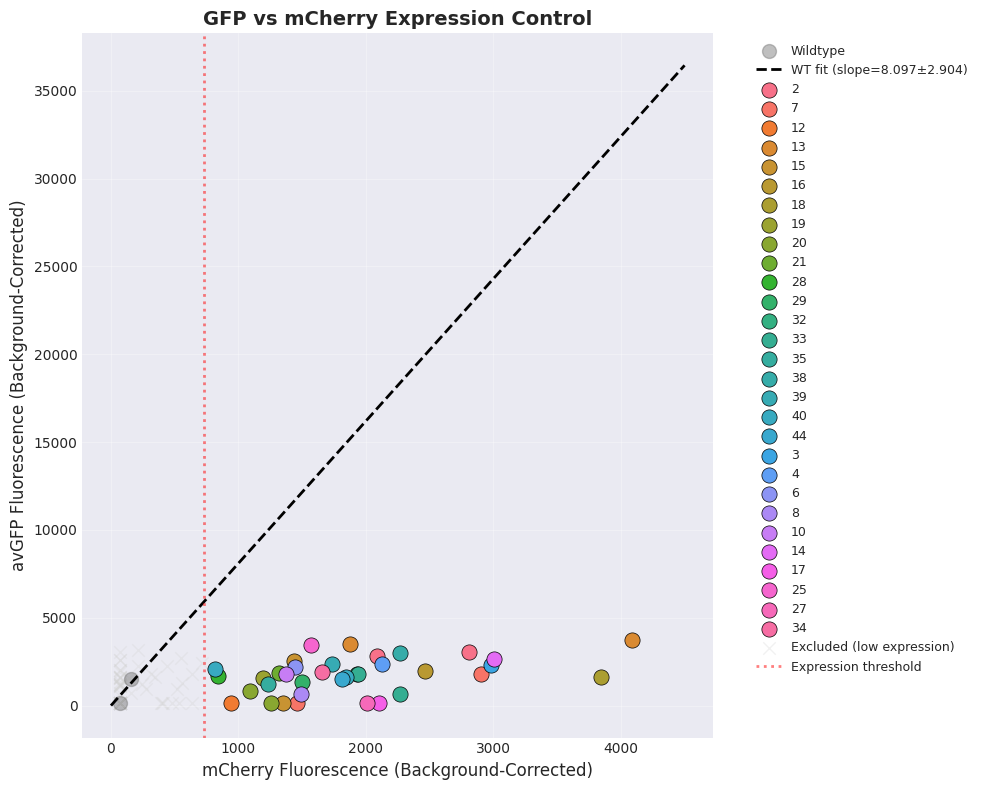

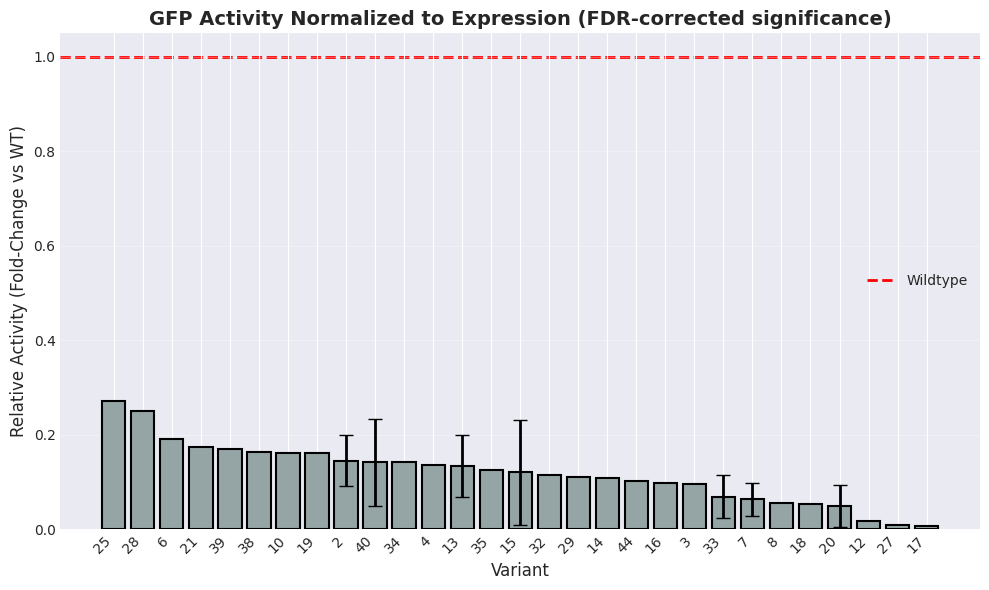


Excluded variants (n=16):
  5: 2 measurements below expression threshold
  9: 2 measurements below expression threshold
  11: 2 measurements below expression threshold
  22: 2 measurements below expression threshold
  23: 2 measurements below expression threshold
  24: 2 measurements below expression threshold
  26: 2 measurements below expression threshold
  30: 2 measurements below expression threshold
  31: 2 measurements below expression threshold
  36: 2 measurements below expression threshold
  37: 2 measurements below expression threshold
  41: 2 measurements below expression threshold
  42: 2 measurements below expression threshold
  43: 2 measurements below expression threshold
  45: 2 measurements below expression threshold
  46: 2 measurements below expression threshold


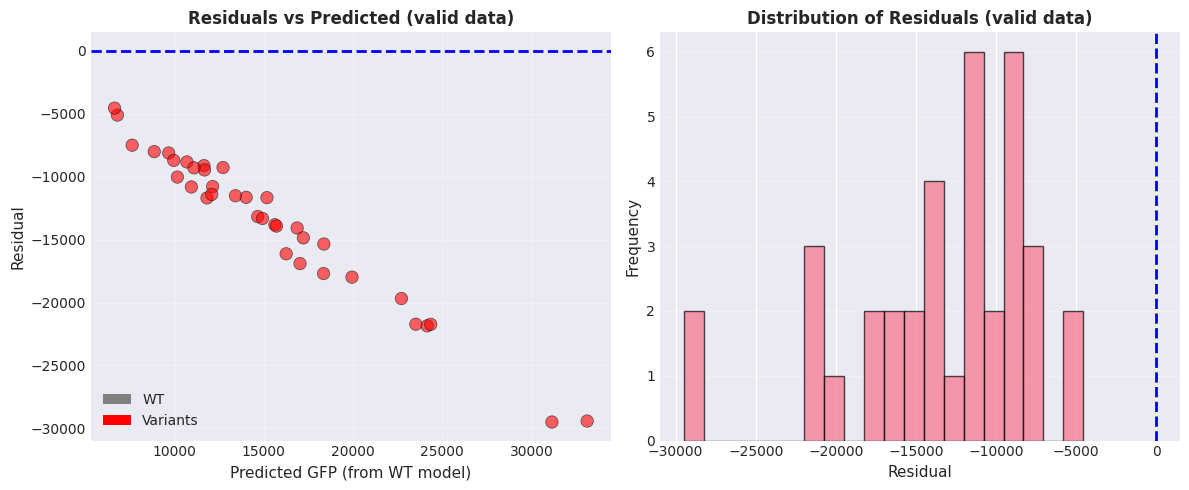


PROTEIN FLUORESCENCE ANALYSIS REPORT

Wildtype Model:
  Slope: 8.097 ± 2.904
  R²: 1.000
  N measurements: 2

Quality Control:
  Expression threshold: 727.0
  Total variant measurements: 90
  Excluded (low expression): 54
  Valid for analysis: 36

Variant Results (sorted by activity):
----------------------------------------------------------------------
25                   | 0.271x ± nan | n=1 | q_value=1.0000 
28                   | 0.249x ± nan | n=1 | q_value=1.0000 
6                    | 0.190x ± nan | n=1 | q_value=1.0000 
21                   | 0.174x ± nan | n=1 | q_value=1.0000 
39                   | 0.169x ± nan | n=1 | q_value=1.0000 
38                   | 0.164x ± nan | n=1 | q_value=1.0000 
10                   | 0.162x ± nan | n=1 | q_value=1.0000 
19                   | 0.161x ± nan | n=1 | q_value=1.0000 
2                    | 0.145x ± 0.054 | n=2 | q_value=1.0000 
40                   | 0.142x ± 0.092 | n=2 | q_value=1.0000 
34                   | 0.142x ± nan | 

In [19]:
# Initialize analyzer
analyzer = ProteinFluorescenceAnalyzer(
    avgfp_rep1=avgfp_rep1,
    mcherry_rep1=mcherry_rep1,
    avgfp_rep2=avgfp_rep2,
    mcherry_rep2=mcherry_rep2
)

# Define your variants
import string

# Generate well names A1–D12
rows = ["A", "B", "C", "D"]
cols = range(1, 13)
wells = [f"{r}{c}" for r in rows for c in cols]

variant_dict = {}

variant_counter = 2
for well in wells:
    if well == "A1":
        variant_dict[well] = "WT"
    elif well == "D11":
        variant_dict[well] = "Blank"
    else:
        variant_dict[well] = str(variant_counter)
        variant_counter += 1

# Sanity check
assert variant_counter == 48  # ensures we labeled exactly 2–47


wt_wells = ['A1']  # Your wildtype wells
blank_wells = ['D11']  # Your blank wells

# Add variant information
analyzer.add_variant_info(variant_dict, wt_wells, blank_wells)

# Run analysis pipeline
analyzer.background_subtraction()
analyzer.fit_wildtype_model()
results = analyzer.calculate_relative_activities(method='slope')

# Generate plots
analyzer.plot_scatter(save_path='/om/user/kspiv/aurora/analysis/wetlab20260203/scatter_plot.png')
analyzer.plot_relative_activity(save_path='/om/user/kspiv/aurora/analysis/wetlab20260203/relative_activity.png')
analyzer.plot_residuals(save_path='/om/user/kspiv/aurora/analysis/wetlab20260203/residuals.png')

# Print report
analyzer.generate_report(use_fdr=True)

# Save results
# results.to_csv('/om/user/kspiv/aurora/analysis/wetlab20260202/variant_activities.csv', index=False)

# # Optional: Bootstrap CI for specific variant
# variant_name = 'Variant1'
# ci_low, ci_high, boot_dist = analyzer.bootstrap_confidence_interval(variant_name)
# print(f"\n{variant_name} Bootstrap 95% CI: [{ci_low:.3f}, {ci_high:.3f}]")

# Export results
analyzer.export_for_publication('/om/user/kspiv/aurora/analysis/wetlab20260203/variant_activities.csv')

In [87]:
idt = pd.read_csv('/om/user/kspiv/aurora/data/IDT_order_jan2026.csv')
del idt['pre-sequence:']
del idt['Unnamed: 0']
idt = idt.drop([0, 1, 2])
idt = idt.iloc[:,:3]
idt.columns = ['model', 'num_mutations', 'seq']
idt['seq_id'] = list(range(1, 47))
idt.set_index('seq_id', inplace=True)

variant_activities = pd.read_csv('/om/user/kspiv/aurora/analysis/wetlab20260202/variant_activities.csv')

final = idt.merge(
    variant_activities[['variant', 'fold_change', 'sem', 'p_value', 'q_value', 'significant_fdr']], 
    left_index=True, 
    right_on='variant', 
    how='left'
)

final.set_index('variant', inplace=True) 




In [93]:
final.to_csv('/om/user/kspiv/aurora/analysis/wetlab20260202/final_analysis.csv', index=True)